In [27]:
# CELL 1: Install Required Packages
# Run this cell first! It may take a few minutes

import sys
import subprocess

packages = [
    'yfinance',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'xgboost',
    'lightgbm',
    'tensorflow',
    'statsmodels',
    'ta',
    'scipy'
]

print("Installing required packages...")
for package in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
        print(f"✓ {package} installed")
    except:
        print(f"✗ {package} installation failed")

print("\n✅ Installation complete! You can now run the rest of the notebook.")

Installing required packages...
✓ yfinance installed
✓ pandas installed
✓ numpy installed
✓ matplotlib installed
✓ seaborn installed
✓ scikit-learn installed
✓ xgboost installed
✓ lightgbm installed
✓ tensorflow installed
✓ statsmodels installed
✓ ta installed
✓ scipy installed

✅ Installation complete! You can now run the rest of the notebook.


In [28]:
# CELL 2: Import All Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Data fetching
import yfinance as yf

# Preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# ML Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Time Series Models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Technical Indicators
import ta

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {__import__('tensorflow').__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All libraries imported successfully!
TensorFlow version: 2.20.0
Pandas version: 2.3.3
NumPy version: 2.3.5


In [31]:
# CELL 3: Configuration - Choose Your Asset

# ============================================
# CONFIGURATION - MODIFY THESE AS NEEDED
# ============================================

# Choose your asset (uncomment one):
# TICKER = 'EURUSD=X'      # EUR/USD Forex pair
# TICKER = 'BTC-USD'       # Bitcoin
TICKER = 'GBPUSD=X'      # GBP/USD Forex pair
# TICKER = 'ETH-USD'       # Ethereum

# Date range
START_DATE = '2019-01-01'
END_DATE = datetime.now().strftime('%Y-%m-%d')

# Model parameters
FORECAST_HORIZON = 5       # Days ahead to predict
TEST_SIZE = 0.2           # 20% for testing
RANDOM_STATE = 42

# Display configuration
print("="*60)
print("CONFIGURATION")
print("="*60)
print(f"Asset: {TICKER}")
print(f"Date Range: {START_DATE} to {END_DATE}")
print(f"Forecast Horizon: {FORECAST_HORIZON} day(s)")
print(f"Test Size: {TEST_SIZE*100}%")
print("="*60)

CONFIGURATION
Asset: GBPUSD=X
Date Range: 2019-01-01 to 2026-01-19
Forecast Horizon: 5 day(s)
Test Size: 20.0%


Fetching data for GBPUSD=X...
This may take a few moments...

✅ Data fetched successfully!
Total records: 1833
Date range: 2019-01-01 to 2026-01-16
Columns: ['Close', 'High', 'Low', 'Open', 'Volume']

📊 First 5 rows:
Price          Close      High       Low      Open  Volume
Date                                                      
2019-01-01  1.273804  1.275673  1.271456  1.275022       0
2019-01-02  1.275429  1.277335  1.258463  1.275234       0
2019-01-03  1.252191  1.263823  1.251878  1.251878       0
2019-01-04  1.262881  1.273966  1.261782  1.262897       0
2019-01-07  1.273496  1.278772  1.272426  1.273285       0

📊 Last 5 rows:
Price          Close      High       Low      Open  Volume
Date                                                      
2026-01-12  1.339423  1.348654  1.339226  1.339441       0
2026-01-13  1.346566  1.348872  1.342660  1.346620       0
2026-01-14  1.342678  1.346257  1.342066  1.342570       0
2026-01-15  1.344267  1.344664  1.336559  1.344068       0


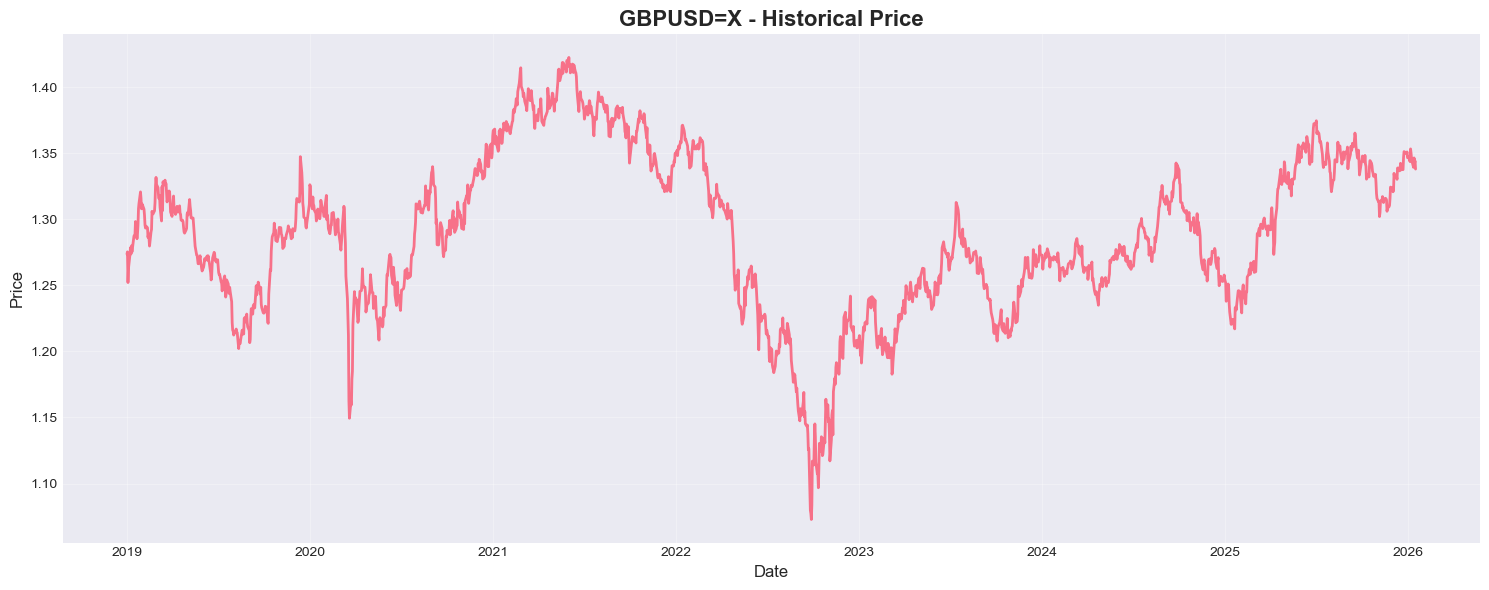

In [32]:
# CELL 4: Fetch Historical Data (FIXED)

print(f"Fetching data for {TICKER}...")
print("This may take a few moments...\n")

# Download data
data = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)

# FIX: Flatten MultiIndex columns if present
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Display info
print(f"✅ Data fetched successfully!")
print(f"Total records: {len(data)}")
print(f"Date range: {data.index[0].date()} to {data.index[-1].date()}")
print(f"Columns: {list(data.columns)}")

# Display first and last few rows
print("\n📊 First 5 rows:")
print(data.head())

print("\n📊 Last 5 rows:")
print(data.tail())

# Basic statistics
print("\n📈 Basic Statistics:")
print(data.describe())

# Check for missing values
print(f"\n🔍 Missing values: {data.isnull().sum().sum()}")

# Plot raw price data
plt.figure(figsize=(15, 6))
plt.plot(data.index, data['Close'], linewidth=2)
plt.title(f'{TICKER} - Historical Price', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
# CELL 5: Feature Engineering - Create Technical Indicators (FIXED)

print("Creating technical features...")
print("This includes: lag features, moving averages, RSI, MACD, Bollinger Bands, etc.\n")

df = data.copy()

# ============================================
# 1. BASIC FEATURES
# ============================================
df['Returns'] = df['Close'].pct_change()
df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))

# ============================================
# 2. LAG FEATURES
# ============================================
print("Creating lag features...")
for lag in [1, 2, 3, 5, 7, 10, 14, 21, 30]:
    df[f'Close_Lag_{lag}'] = df['Close'].shift(lag)
    df[f'Returns_Lag_{lag}'] = df['Returns'].shift(lag)
    if 'Volume' in df.columns:
        df[f'Volume_Lag_{lag}'] = df['Volume'].shift(lag)

# ============================================
# 3. MOVING AVERAGES (FIXED - Added 12, 26)
# ============================================
print("Creating moving averages...")
for window in [5, 10, 12, 20, 26, 30, 50, 100, 200]:
    df[f'SMA_{window}'] = df['Close'].rolling(window=window).mean()
    df[f'EMA_{window}'] = df['Close'].ewm(span=window, adjust=False).mean()
    df[f'STD_{window}'] = df['Close'].rolling(window=window).std()
    df[f'MIN_{window}'] = df['Close'].rolling(window=window).min()
    df[f'MAX_{window}'] = df['Close'].rolling(window=window).max()

# ============================================
# 4. TECHNICAL INDICATORS (using TA library)
# ============================================
print("Creating technical indicators...")

# Trend Indicators
try:
    df['MACD'] = ta.trend.macd(df['Close'])
    df['MACD_Signal'] = ta.trend.macd_signal(df['Close'])
    df['MACD_Diff'] = ta.trend.macd_diff(df['Close'])
except Exception as e:
    print(f"Warning: MACD calculation failed: {e}")
    df['MACD'] = 0
    df['MACD_Signal'] = 0
    df['MACD_Diff'] = 0

# Momentum Indicators
try:
    df['RSI'] = ta.momentum.rsi(df['Close'], window=14)
    df['RSI_30'] = ta.momentum.rsi(df['Close'], window=30)
except Exception as e:
    print(f"Warning: RSI calculation failed: {e}")
    df['RSI'] = 50
    df['RSI_30'] = 50

try:
    df['Stochastic'] = ta.momentum.stoch(df['High'], df['Low'], df['Close'])
except Exception as e:
    print(f"Warning: Stochastic calculation failed: {e}")
    df['Stochastic'] = 50

try:
    df['Williams_R'] = ta.momentum.williams_r(df['High'], df['Low'], df['Close'])
except Exception as e:
    print(f"Warning: Williams %R calculation failed: {e}")
    df['Williams_R'] = -50

try:
    df['ROC'] = ta.momentum.roc(df['Close'], window=12)
except Exception as e:
    print(f"Warning: ROC calculation failed: {e}")
    df['ROC'] = 0

# Volatility Indicators
try:
    df['BB_High'] = ta.volatility.bollinger_hband(df['Close'])
    df['BB_Low'] = ta.volatility.bollinger_lband(df['Close'])
    df['BB_Mid'] = ta.volatility.bollinger_mavg(df['Close'])
    df['BB_Width'] = df['BB_High'] - df['BB_Low']
    
    # Prevent division by zero
    bb_denominator = df['BB_High'] - df['BB_Low']
    bb_denominator = bb_denominator.replace(0, np.nan)
    df['BB_Pct'] = (df['Close'] - df['BB_Low']) / bb_denominator
except Exception as e:
    print(f"Warning: Bollinger Bands calculation failed: {e}")
    df['BB_High'] = df['Close']
    df['BB_Low'] = df['Close']
    df['BB_Mid'] = df['Close']
    df['BB_Width'] = 0
    df['BB_Pct'] = 0.5

try:
    df['ATR'] = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'])
except Exception as e:
    print(f"Warning: ATR calculation failed: {e}")
    df['ATR'] = df['High'] - df['Low']

try:
    df['Keltner_High'] = ta.volatility.keltner_channel_hband(df['High'], df['Low'], df['Close'])
    df['Keltner_Low'] = ta.volatility.keltner_channel_lband(df['High'], df['Low'], df['Close'])
except Exception as e:
    print(f"Warning: Keltner Channel calculation failed: {e}")
    df['Keltner_High'] = df['Close']
    df['Keltner_Low'] = df['Close']

# Volume Indicators (if volume available) - FIXED
if 'Volume' in df.columns:
    volume_sum = df['Volume'].sum()
    if volume_sum > 0:
        print("Creating volume indicators...")
        try:
            df['Volume_SMA_20'] = df['Volume'].rolling(window=20).mean()
            df['OBV'] = ta.volume.on_balance_volume(df['Close'], df['Volume'])
            df['MFI'] = ta.volume.money_flow_index(df['High'], df['Low'], df['Close'], df['Volume'])
            df['Volume_Price_Trend'] = ta.volume.volume_price_trend(df['Close'], df['Volume'])
        except Exception as e:
            print(f"Warning: Volume indicators calculation failed: {e}")
            df['Volume_SMA_20'] = df['Volume']
            df['OBV'] = 0
            df['MFI'] = 50
            df['Volume_Price_Trend'] = 0
    else:
        print("No volume data available, skipping volume indicators...")

# ============================================
# 5. PRICE PATTERNS
# ============================================
print("Creating price pattern features...")
df['HL_Range'] = df['High'] - df['Low']
df['OC_Range'] = abs(df['Open'] - df['Close'])

# Prevent division by zero
hl_denominator = df['High'] - df['Low']
hl_denominator = hl_denominator.replace(0, np.nan)
df['Price_Position'] = (df['Close'] - df['Low']) / hl_denominator

# ============================================
# 6. MOMENTUM FEATURES
# ============================================
print("Creating momentum features...")
for period in [5, 10, 20, 30]:
    df[f'Momentum_{period}'] = df['Close'] - df['Close'].shift(period)
    df[f'ROC_{period}'] = df['Close'].pct_change(periods=period)

# ============================================
# 7. VOLATILITY FEATURES
# ============================================
print("Creating volatility features...")
for window in [10, 20, 30]:
    df[f'Volatility_{window}'] = df['Returns'].rolling(window=window).std()
    df[f'Realized_Volatility_{window}'] = df['Returns'].rolling(window=window).std() * np.sqrt(252)

# ============================================
# 8. TIME-BASED FEATURES
# ============================================
print("Creating time-based features...")
df['Day_of_Week'] = df.index.dayofweek
df['Day_of_Month'] = df.index.day

# FIX: Handle isocalendar() properly for different pandas versions
try:
    df['Week_of_Year'] = df.index.isocalendar().week.values
except:
    df['Week_of_Year'] = df.index.week

df['Month'] = df.index.month
df['Quarter'] = df.index.quarter
df['Year'] = df.index.year
df['Is_Month_Start'] = df.index.is_month_start.astype(int)
df['Is_Month_End'] = df.index.is_month_end.astype(int)
df['Is_Quarter_Start'] = df.index.is_quarter_start.astype(int)
df['Is_Quarter_End'] = df.index.is_quarter_end.astype(int)

# ============================================
# 9. INTERACTION FEATURES
# ============================================
print("Creating interaction features...")
if 'Volume' in df.columns:
    df['Price_x_Volume'] = df['Close'] * df['Volume']
else:
    df['Price_x_Volume'] = 0

# Prevent division by zero for ratios
df['SMA_20_50_Ratio'] = df['SMA_20'] / df['SMA_50'].replace(0, np.nan)
df['EMA_12_26_Ratio'] = df['EMA_12'] / df['EMA_26'].replace(0, np.nan)

# ============================================
# 10. CLEAN UP
# ============================================
print("\nCleaning data...")

# Replace infinite values with NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Drop NaN values
df_cleaned = df.dropna()

print(f"\n✅ Feature engineering complete!")
print(f"Total features created: {len(df_cleaned.columns)}")
print(f"Rows after cleaning: {len(df_cleaned)} (removed {len(df) - len(df_cleaned)} rows with NaN)")

if len(df_cleaned) == 0:
    print("\n⚠️ WARNING: All rows were removed! Check your data.")
else:
    print(f"\nFeature categories:")
    print(f"  - Lag features: {len([c for c in df_cleaned.columns if 'Lag' in c])}")
    print(f"  - Moving averages: {len([c for c in df_cleaned.columns if 'MA' in c])}")
    print(f"  - Technical indicators: {len([c for c in df_cleaned.columns if any(x in c for x in ['RSI', 'MACD', 'BB', 'ATR', 'Stochastic'])])}")
    print(f"  - Time features: {len([c for c in df_cleaned.columns if any(x in c for x in ['Day', 'Week', 'Month', 'Quarter', 'Year'])])}")

# Store cleaned data
data_with_features = df_cleaned.copy()

print("\n✅ Data ready for modeling!")

Creating technical features...
This includes: lag features, moving averages, RSI, MACD, Bollinger Bands, etc.

Creating lag features...
Creating moving averages...
Creating technical indicators...
No volume data available, skipping volume indicators...
Creating price pattern features...
Creating momentum features...
Creating volatility features...
Creating time-based features...
Creating interaction features...

Cleaning data...

✅ Feature engineering complete!
Total features created: 125
Rows after cleaning: 1634 (removed 199 rows with NaN)

Feature categories:
  - Lag features: 27
  - Moving averages: 32
  - Technical indicators: 12
  - Time features: 10

✅ Data ready for modeling!


DATA PREPARATION SUMMARY
Total samples: 1629
Training samples: 1303 (80.0%)
Testing samples: 326 (20.0%)
Number of features: 120

Train date range: 2019-10-08 to 2024-10-03
Test date range: 2024-10-04 to 2026-01-09

Target variable: Predict GBPUSD=X price 5 day(s) ahead


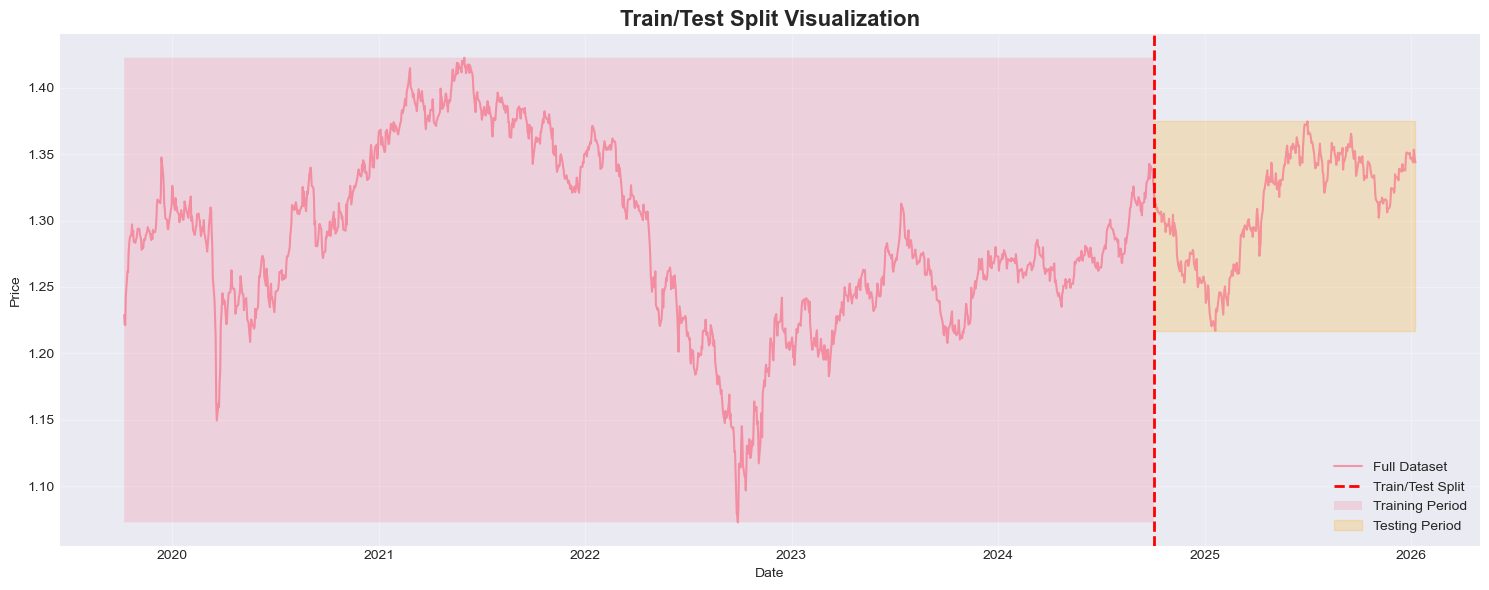

In [34]:
# CELL 6: Create Target Variable and Prepare Train/Test Sets

# Create target (future price)
data_with_features['Target'] = data_with_features['Close'].shift(-FORECAST_HORIZON)
data_with_features = data_with_features.dropna()

# Define feature columns (exclude OHLCV and target)
exclude_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Target']
feature_cols = [col for col in data_with_features.columns if col not in exclude_cols]

X = data_with_features[feature_cols]
y = data_with_features['Target']

# Time series split (preserve temporal order)
split_idx = int(len(data_with_features) * (1 - TEST_SIZE))

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

# For LSTM - scale the data
scaler_X = StandardScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

print("="*60)
print("DATA PREPARATION SUMMARY")
print("="*60)
print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"Number of features: {len(feature_cols)}")
print(f"\nTrain date range: {X_train.index[0].date()} to {X_train.index[-1].date()}")
print(f"Test date range: {X_test.index[0].date()} to {X_test.index[-1].date()}")
print(f"\nTarget variable: Predict {TICKER} price {FORECAST_HORIZON} day(s) ahead")
print("="*60)

# Visualize train/test split
plt.figure(figsize=(15, 6))
plt.plot(data_with_features.index, data_with_features['Close'], label='Full Dataset', alpha=0.7)
plt.axvline(x=X_test.index[0], color='red', linestyle='--', linewidth=2, label='Train/Test Split')
plt.fill_between(X_train.index, data_with_features.loc[X_train.index, 'Close'].min(), 
                 data_with_features.loc[X_train.index, 'Close'].max(), alpha=0.2, label='Training Period')
plt.fill_between(X_test.index, data_with_features.loc[X_test.index, 'Close'].min(), 
                 data_with_features.loc[X_test.index, 'Close'].max(), alpha=0.2, color='orange', label='Testing Period')
plt.title('Train/Test Split Visualization', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# CELL 7: Define Evaluation Functions

def evaluate_model(name, y_train_true, y_train_pred, y_test_true, y_test_pred, verbose=True):
    """Comprehensive model evaluation"""
    
    # Ensure arrays
    y_train_true = np.array(y_train_true).flatten()
    y_train_pred = np.array(y_train_pred).flatten()
    y_test_true = np.array(y_test_true).flatten()
    y_test_pred = np.array(y_test_pred).flatten()
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
    
    train_mae = mean_absolute_error(y_train_true, y_train_pred)
    test_mae = mean_absolute_error(y_test_true, y_test_pred)
    
    train_r2 = r2_score(y_train_true, y_train_pred)
    test_r2 = r2_score(y_test_true, y_test_pred)
    
    train_mape = mean_absolute_percentage_error(y_train_true, y_train_pred) * 100
    test_mape = mean_absolute_percentage_error(y_test_true, y_test_pred) * 100
    
    # Directional accuracy
    if len(y_train_true) > 1:
        train_direction_acc = np.mean(
            np.sign(y_train_pred[1:] - y_train_true[:-1]) == 
            np.sign(y_train_true[1:] - y_train_true[:-1])
        ) * 100
    else:
        train_direction_acc = 0
        
    if len(y_test_true) > 1:
        test_direction_acc = np.mean(
            np.sign(y_test_pred[1:] - y_test_true[:-1]) == 
            np.sign(y_test_true[1:] - y_test_true[:-1])
        ) * 100
    else:
        test_direction_acc = 0
    
    results = {
        'Model': name,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_MAPE': train_mape,
        'Test_MAPE': test_mape,
        'Train_Direction': train_direction_acc,
        'Test_Direction': test_direction_acc
    }
    
    if verbose:
        print("\n" + "="*70)
        print(f"{name} - PERFORMANCE METRICS")
        print("="*70)
        print(f"{'Metric':<20} {'Training':<20} {'Testing':<20}")
        print("-"*70)
        print(f"{'RMSE':<20} {train_rmse:<20.6f} {test_rmse:<20.6f}")
        print(f"{'MAE':<20} {train_mae:<20.6f} {test_mae:<20.6f}")
        print(f"{'R² Score':<20} {train_r2:<20.6f} {test_r2:<20.6f}")
        print(f"{'MAPE (%)':<20} {train_mape:<20.2f} {test_mape:<20.2f}")
        print(f"{'Direction Acc (%)':<20} {train_direction_acc:<20.2f} {test_direction_acc:<20.2f}")
        print("="*70)
    
    return results


def plot_predictions(y_true, y_pred, title, dates=None):
    """Plot actual vs predicted values"""
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    
    # Plot 1: Actual vs Predicted
    if dates is not None:
        axes[0].plot(dates, y_true, label='Actual', linewidth=2, alpha=0.8)
        axes[0].plot(dates, y_pred, label='Predicted', linewidth=2, alpha=0.8)
    else:
        axes[0].plot(y_true, label='Actual', linewidth=2, alpha=0.8)
        axes[0].plot(y_pred, label='Predicted', linewidth=2, alpha=0.8)
    
    axes[0].set_title(f'{title} - Actual vs Predicted', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Date' if dates is not None else 'Time Step')
    axes[0].set_ylabel('Price')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Prediction Error
    error = y_true - y_pred
    if dates is not None:
        axes[1].plot(dates, error, color='red', linewidth=1, alpha=0.7)
    else:
        axes[1].plot(error, color='red', linewidth=1, alpha=0.7)
    
    axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
    axes[1].fill_between(range(len(error)) if dates is None else dates, error, 0, alpha=0.3, color='red')
    axes[1].set_title('Prediction Error', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Date' if dates is not None else 'Time Step')
    axes[1].set_ylabel('Error')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# Initialize results storage
all_results = []

print("✅ Evaluation functions ready!")

✅ Evaluation functions ready!


🌲 Training Random Forest Regressor...

Random Forest - PERFORMANCE METRICS
Metric               Training             Testing             
----------------------------------------------------------------------
RMSE                 0.004229             0.016363            
MAE                  0.002605             0.012556            
R² Score             0.995823             0.827991            
MAPE (%)             0.21                 0.95                
Direction Acc (%)    83.64                56.00               


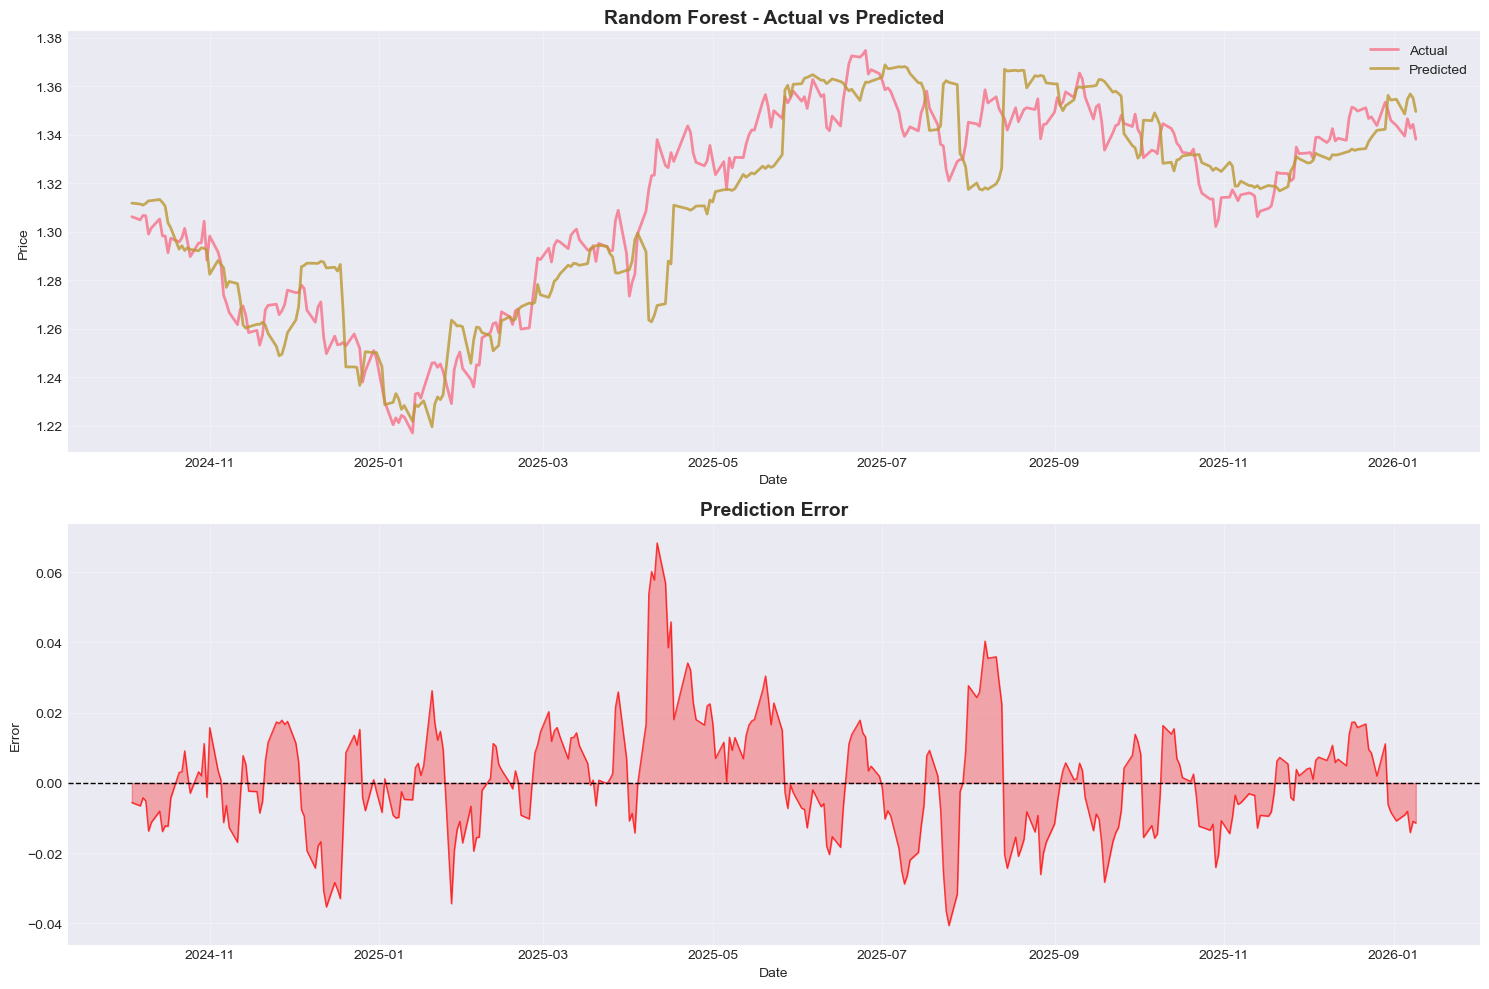

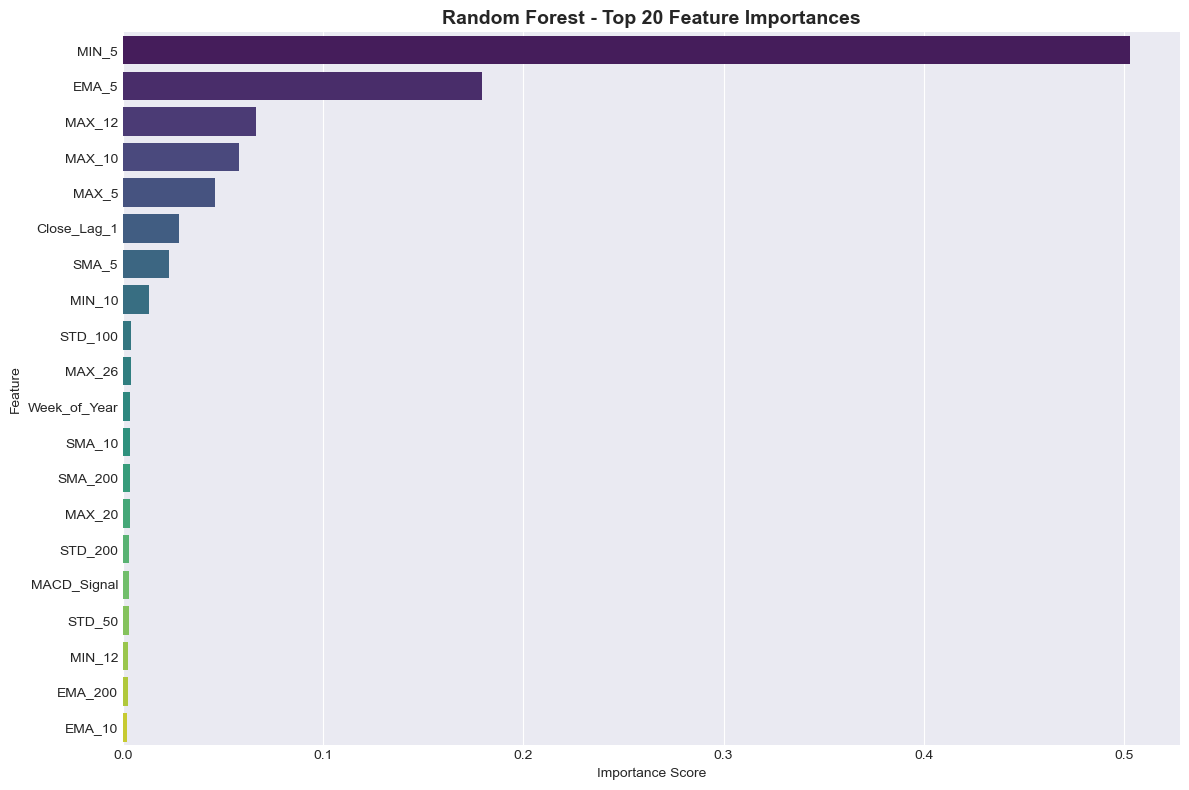


✅ Random Forest training complete!


In [36]:
# CELL 8: Train Random Forest Model

print("🌲 Training Random Forest Regressor...")

# Train model
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

rf_model.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Evaluate
rf_results = evaluate_model('Random Forest', y_train, y_train_pred_rf, y_test, y_test_pred_rf)
all_results.append(rf_results)

# Plot
plot_predictions(y_test.values, y_test_pred_rf, 'Random Forest', dates=y_test.index)

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance.head(20), x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest - Top 20 Feature Importances', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\n✅ Random Forest training complete!")

🚀 Training XGBoost Regressor...

XGBoost - PERFORMANCE METRICS
Metric               Training             Testing             
----------------------------------------------------------------------
RMSE                 0.000559             0.018318            
MAE                  0.000426             0.014300            
R² Score             0.999927             0.784435            
MAPE (%)             0.03                 1.09                
Direction Acc (%)    97.08                53.54               


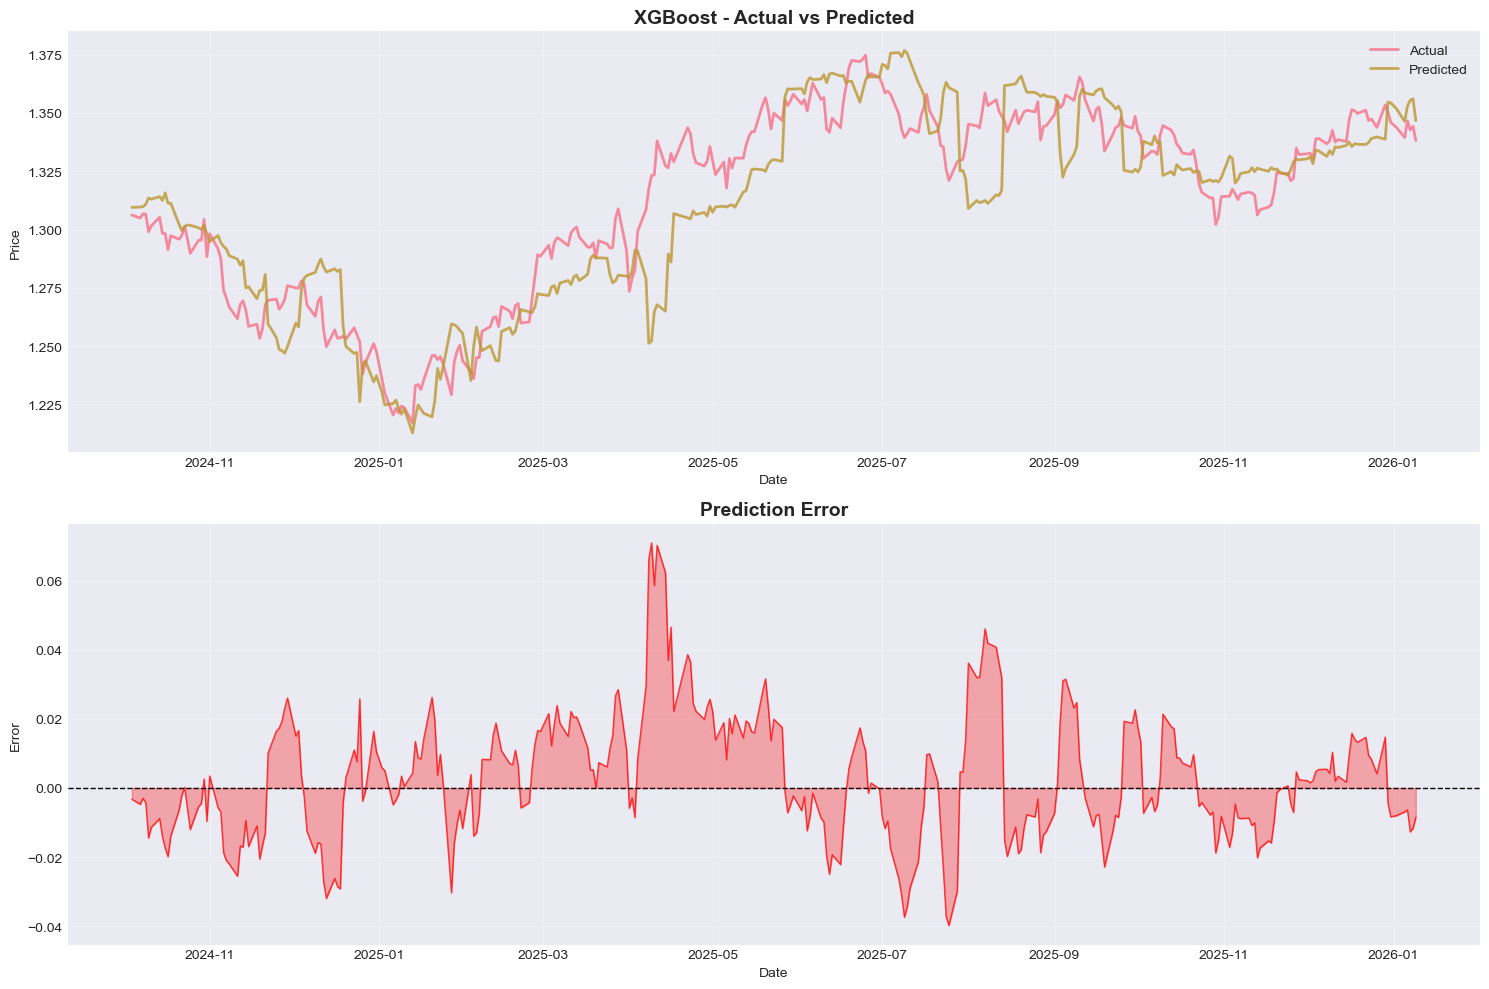

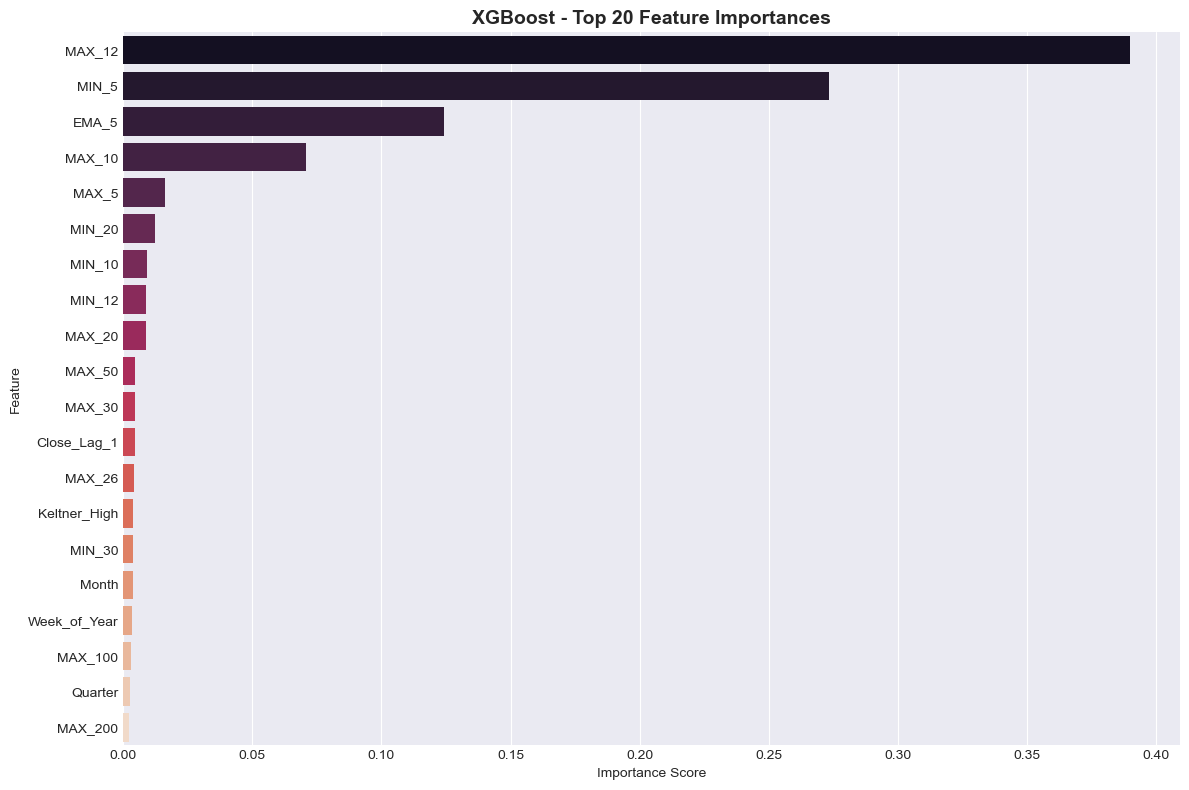


✅ XGBoost training complete!


In [37]:
# CELL 9: Train XGBoost Model

print("🚀 Training XGBoost Regressor...")

# Train model
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(X_train, y_train)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Evaluate
xgb_results = evaluate_model('XGBoost', y_train, y_train_pred_xgb, y_test, y_test_pred_xgb)
all_results.append(xgb_results)

# Plot
plot_predictions(y_test.values, y_test_pred_xgb, 'XGBoost', dates=y_test.index)

# Feature importance
feature_importance_xgb = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_xgb.head(20), x='Importance', y='Feature', palette='rocket')
plt.title('XGBoost - Top 20 Feature Importances', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\n✅ XGBoost training complete!")

💡 Training LightGBM Regressor...

LightGBM - PERFORMANCE METRICS
Metric               Training             Testing             
----------------------------------------------------------------------
RMSE                 0.002767             0.019717            
MAE                  0.001799             0.014737            
R² Score             0.998570             0.760206            
MAPE (%)             0.14                 1.14                
Direction Acc (%)    88.63                52.69               


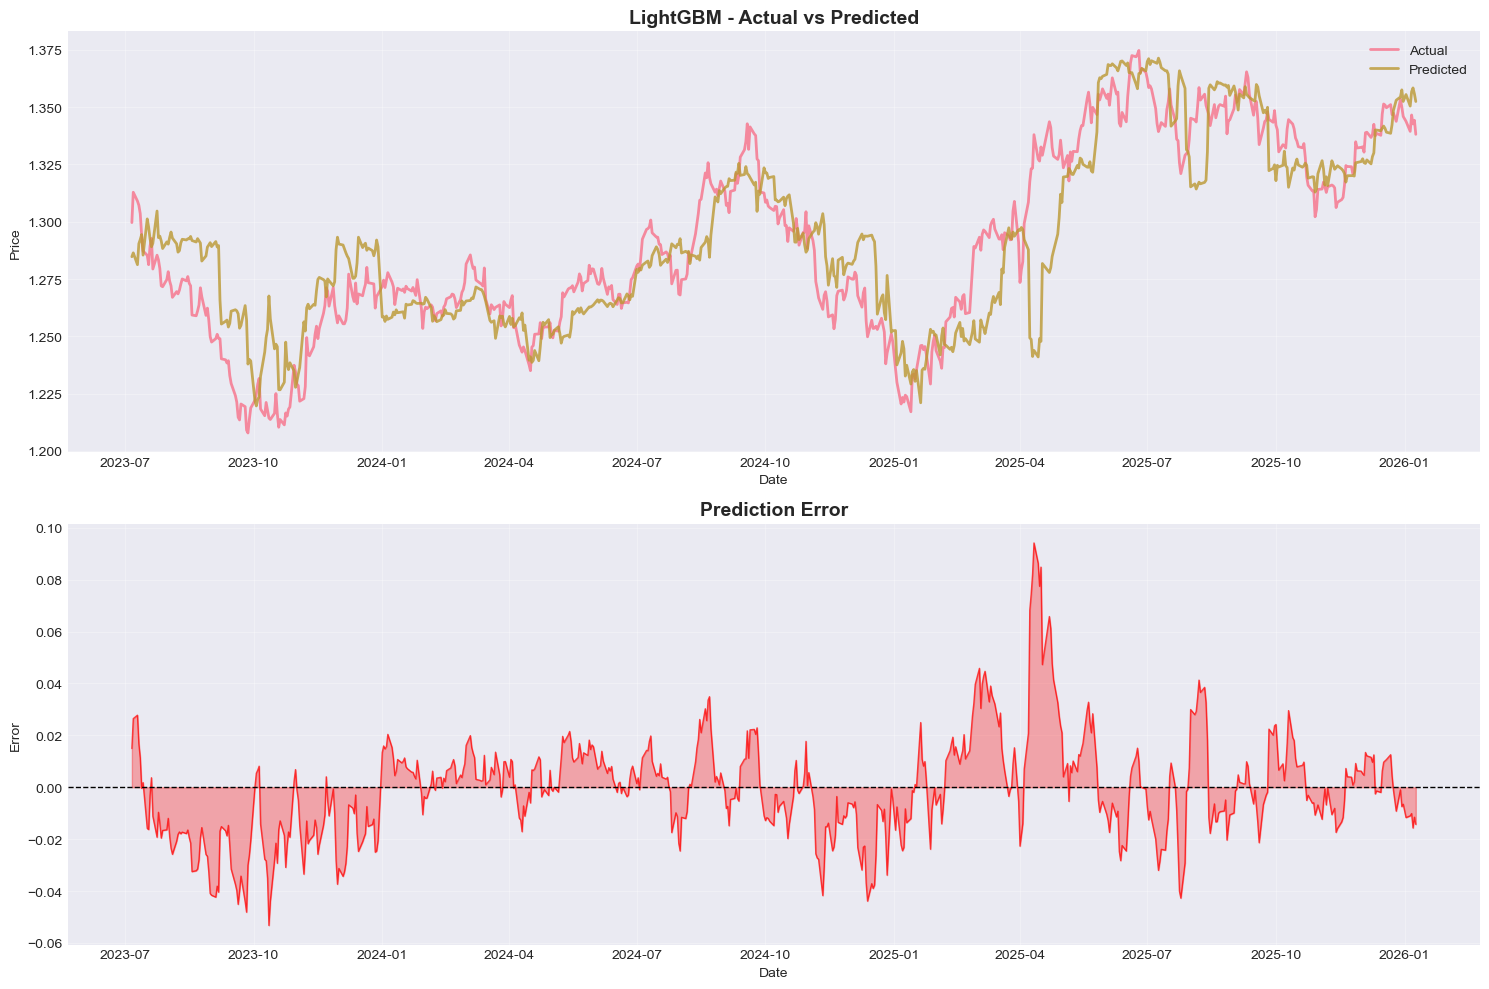


✅ LightGBM training complete!


In [25]:
# CELL 10: Train LightGBM Model

print("💡 Training LightGBM Regressor...")

# Train model
lgbm_model = LGBMRegressor(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.05,
    num_leaves=31,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)

# Predictions
y_train_pred_lgbm = lgbm_model.predict(X_train)
y_test_pred_lgbm = lgbm_model.predict(X_test)

# Evaluate
lgbm_results = evaluate_model('LightGBM', y_train, y_train_pred_lgbm, y_test, y_test_pred_lgbm)
all_results.append(lgbm_results)

# Plot
plot_predictions(y_test.values, y_test_pred_lgbm, 'LightGBM', dates=y_test.index)

print("\n✅ LightGBM training complete!")

🧠 Training LSTM Neural Network...
LSTM Training shape: (917, 60, 120)
LSTM Testing shape: (592, 60, 120)

Training LSTM (this may take a few minutes)...
Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 314ms/step - loss: 0.1017 - mae: 0.2462 - val_loss: 0.0090 - val_mae: 0.0765 - learning_rate: 0.0010
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - loss: 0.0160 - mae: 0.0984 - val_loss: 0.0074 - val_mae: 0.0727 - learning_rate: 0.0010
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step - loss: 0.0110 - mae: 0.0826 - val_loss: 0.0096 - val_mae: 0.0871 - learning_rate: 0.0010
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step - loss: 0.0091 - mae: 0.0752 - val_loss: 0.0119 - val_mae: 0.0981 - learning_rate: 0.0010
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 171ms/step - loss: 0.0093 - mae: 0.0748 - val_loss: 0.0090 - val_mae: 0.0807 - learning_rate: 0.0010
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 236ms/step - loss: 0.0075 - mae: 0.0684 - val_loss: 0.0128 - val_mae: 0.0996 - learning_r

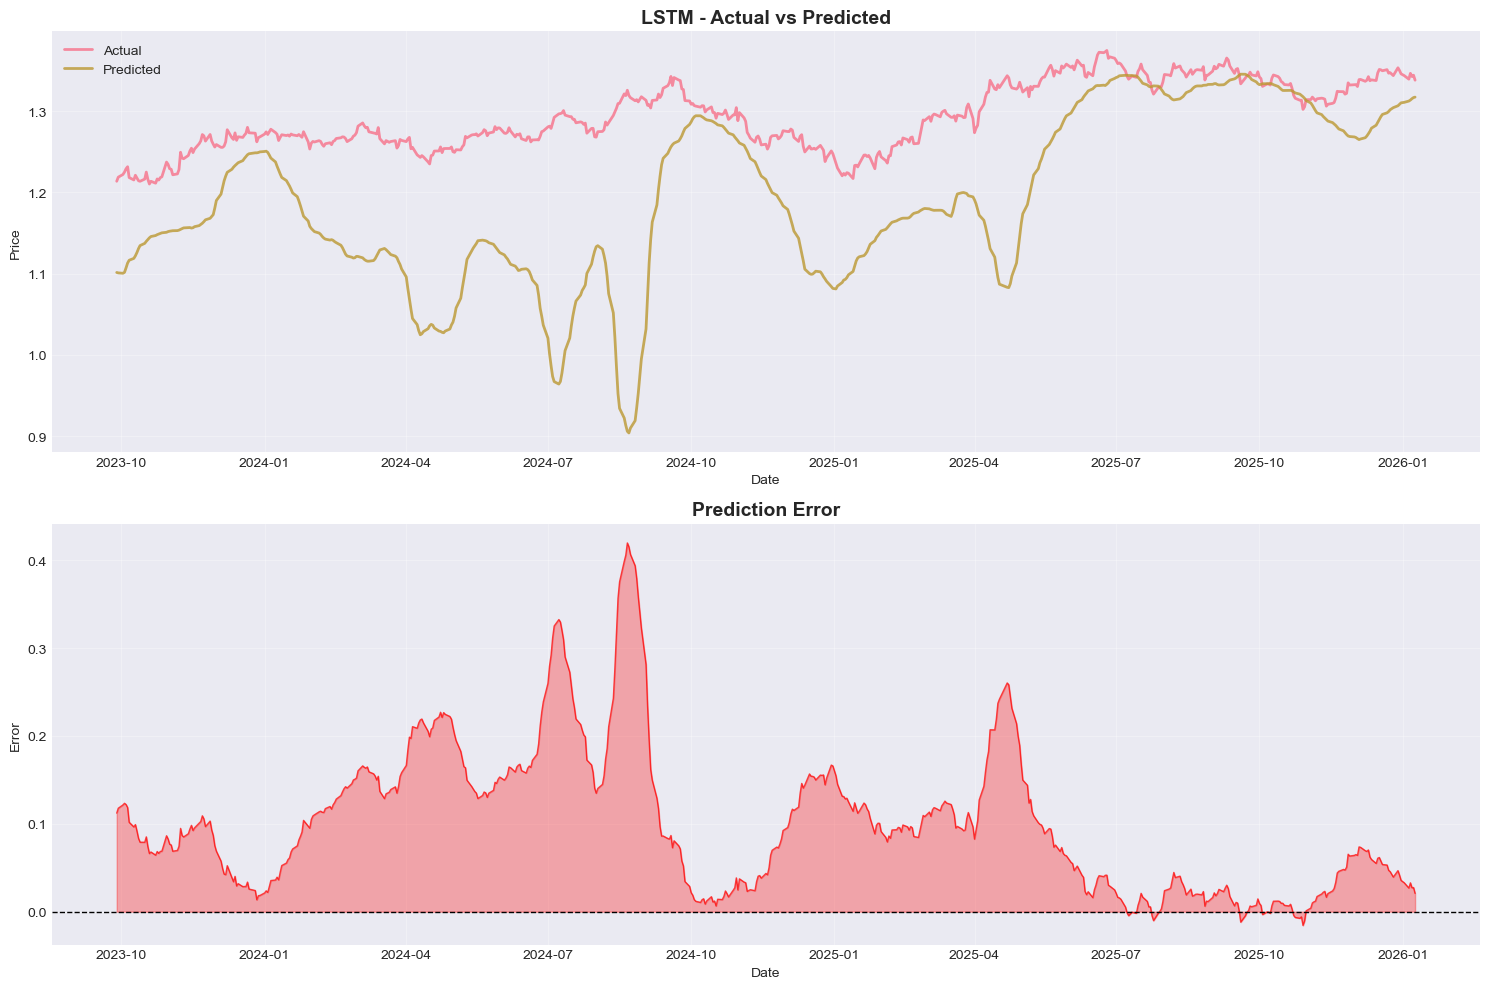

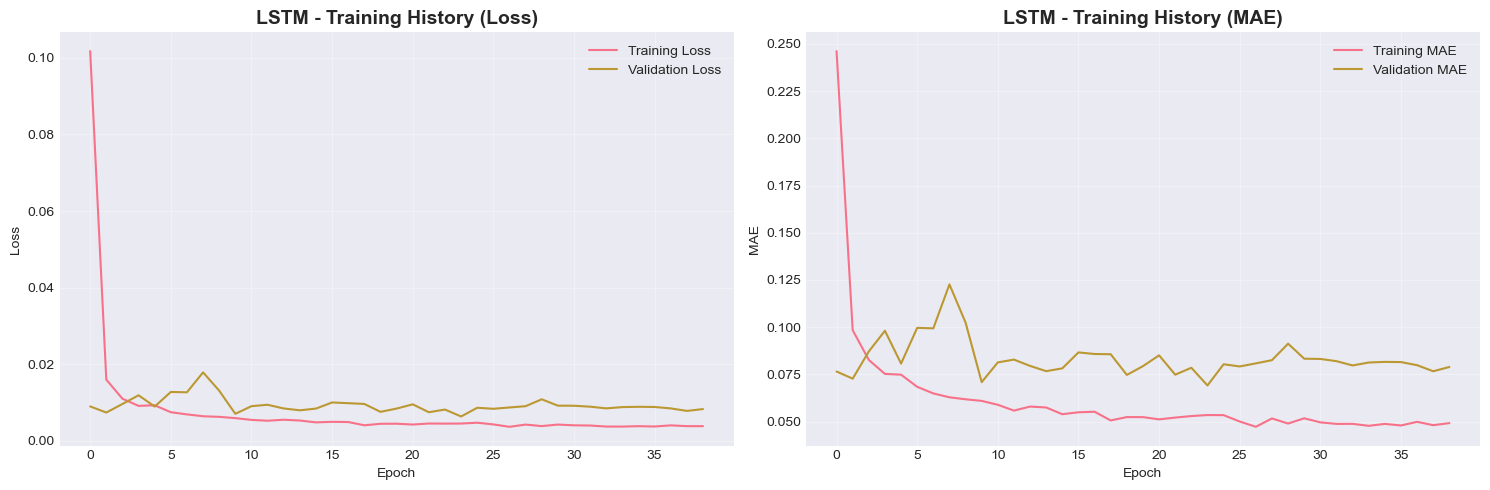


✅ LSTM training complete!


In [26]:
# CELL 11: Train LSTM Model

print("🧠 Training LSTM Neural Network...")

# Prepare sequences for LSTM
def create_sequences(X, y, lookback=60):
    X_seq, y_seq = [], []
    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

LOOKBACK = 60

X_train_lstm, y_train_lstm = create_sequences(X_train_scaled, y_train_scaled, LOOKBACK)
X_test_lstm, y_test_lstm = create_sequences(X_test_scaled, y_test_scaled, LOOKBACK)

print(f"LSTM Training shape: {X_train_lstm.shape}")
print(f"LSTM Testing shape: {X_test_lstm.shape}")

# Build LSTM model
lstm_model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(LOOKBACK, X_train_lstm.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)

# Train
print("\nTraining LSTM (this may take a few minutes)...")
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Predictions
y_train_pred_lstm_scaled = lstm_model.predict(X_train_lstm, verbose=0)
y_test_pred_lstm_scaled = lstm_model.predict(X_test_lstm, verbose=0)

# Inverse transform
y_train_pred_lstm = scaler_y.inverse_transform(y_train_pred_lstm_scaled).flatten()
y_test_pred_lstm = scaler_y.inverse_transform(y_test_pred_lstm_scaled).flatten()

y_train_lstm_actual = y_train.values[LOOKBACK:]
y_test_lstm_actual = y_test.values[LOOKBACK:]

# Evaluate
lstm_results = evaluate_model('LSTM', y_train_lstm_actual, y_train_pred_lstm, 
                               y_test_lstm_actual, y_test_pred_lstm)
all_results.append(lstm_results)

# Plot predictions
plot_predictions(y_test_lstm_actual, y_test_pred_lstm, 'LSTM', dates=y_test.index[LOOKBACK:])

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('LSTM - Training History (Loss)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('LSTM - Training History (MAE)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ LSTM training complete!")

📈 Training ARIMA Model...

Checking stationarity of price series:
ADF Statistic: -2.188265
p-value: 0.210532
✗ Series is not stationary

Fitting ARIMA model (this may take a moment)...


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1306
Model:                 ARIMA(1, 1, 1)   Log Likelihood                4580.560
Date:                Sat, 17 Jan 2026   AIC                          -9155.120
Time:                        20:33:26   BIC                          -9139.598
Sample:                    10-08-2019   HQIC                         -9149.297
                         - 10-08-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3176      0.399      0.796      0.426      -0.464       1.099
ma.L1         -0.2732      0.407     -0.671      0.502      -1.071       0.524
sigma2       5.23e-05   1.26e-06     41.611      0.0

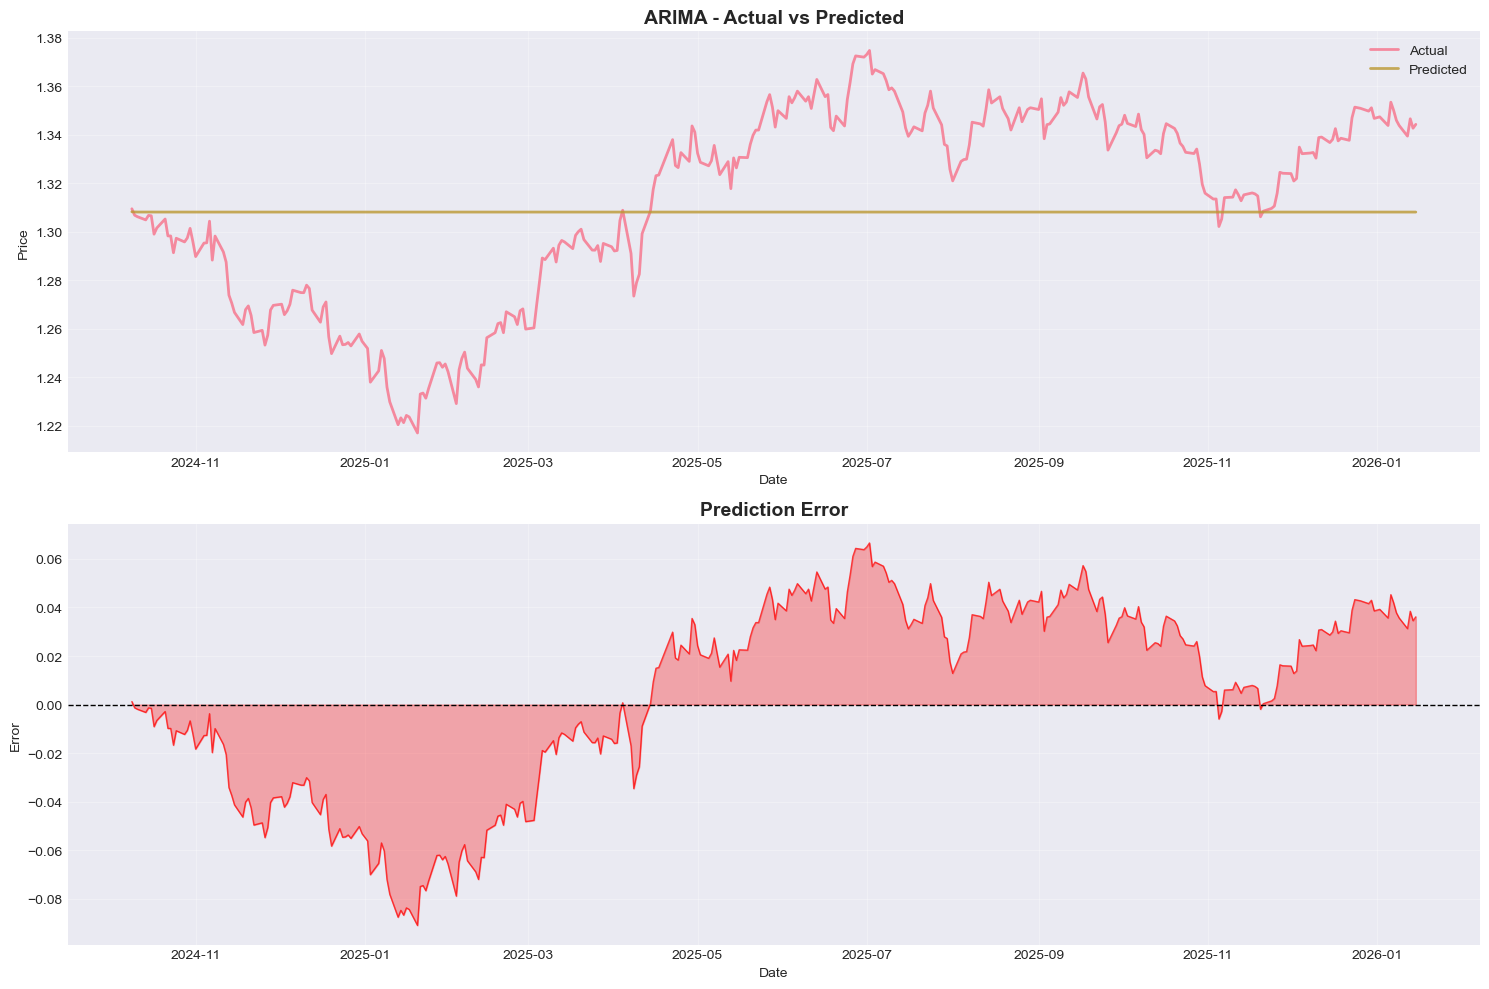


✅ ARIMA training complete!


In [12]:
# CELL 12: Train ARIMA Model

print("📈 Training ARIMA Model...")

# Use only closing prices for ARIMA
price_series = data_with_features['Close']

# Split
train_size = int(len(price_series) * (1 - TEST_SIZE))
train_arima = price_series[:train_size]
test_arima = price_series[train_size:]

# Stationarity test
def check_stationarity(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    if result[1] <= 0.05:
        print("✓ Series is stationary")
        return True
    else:
        print("✗ Series is not stationary")
        return False

print("\nChecking stationarity of price series:")
is_stationary = check_stationarity(train_arima)

# Train ARIMA model
print("\nFitting ARIMA model (this may take a moment)...")
try:
    # Try ARIMA(1,1,1) as starting point
    arima_model = ARIMA(train_arima, order=(1, 1, 1))
    arima_fitted = arima_model.fit()
    
    print(arima_fitted.summary())
    
    # Forecast
    forecast_steps = len(test_arima)
    forecast = arima_fitted.forecast(steps=forecast_steps)
    
    # For training predictions, use in-sample predictions
    train_pred_arima = arima_fitted.fittedvalues
    test_pred_arima = forecast
    
    # Align for evaluation
    y_train_arima = train_arima[1:]  # ARIMA starts from index 1
    y_train_pred_arima = train_pred_arima[1:]
    
    # Evaluate
    arima_results = evaluate_model('ARIMA', y_train_arima, y_train_pred_arima, 
                                    test_arima, test_pred_arima)
    all_results.append(arima_results)
    
    # Plot
    plot_predictions(test_arima.values, test_pred_arima.values, 'ARIMA', dates=test_arima.index)
    
    print("\n✅ ARIMA training complete!")
    
except Exception as e:
    print(f"\n⚠️ ARIMA training failed: {str(e)}")
    print("This is normal for some assets. Continuing with other models...")

MODEL COMPARISON - ALL MODELS

📊 Test Set Performance Comparison:

         Model  Test_RMSE  Test_MAE   Test_R2  Test_MAPE  Test_Direction
Random Forest   0.006022  0.004656  0.976636   0.355471       64.723926
      XGBoost   0.005778  0.004360  0.978488   0.332047       67.484663
     LightGBM   0.004755  0.003689  0.985429   0.281913       72.392638
         LSTM   0.023205  0.017549  0.640607   1.331504       46.616541
        ARIMA   0.039586  0.034581 -0.011007   2.650225       51.226994

🏆 Best Model by RMSE: LightGBM
🏆 Best Model by R²: LightGBM
🏆 Best Model by Direction Accuracy: LightGBM


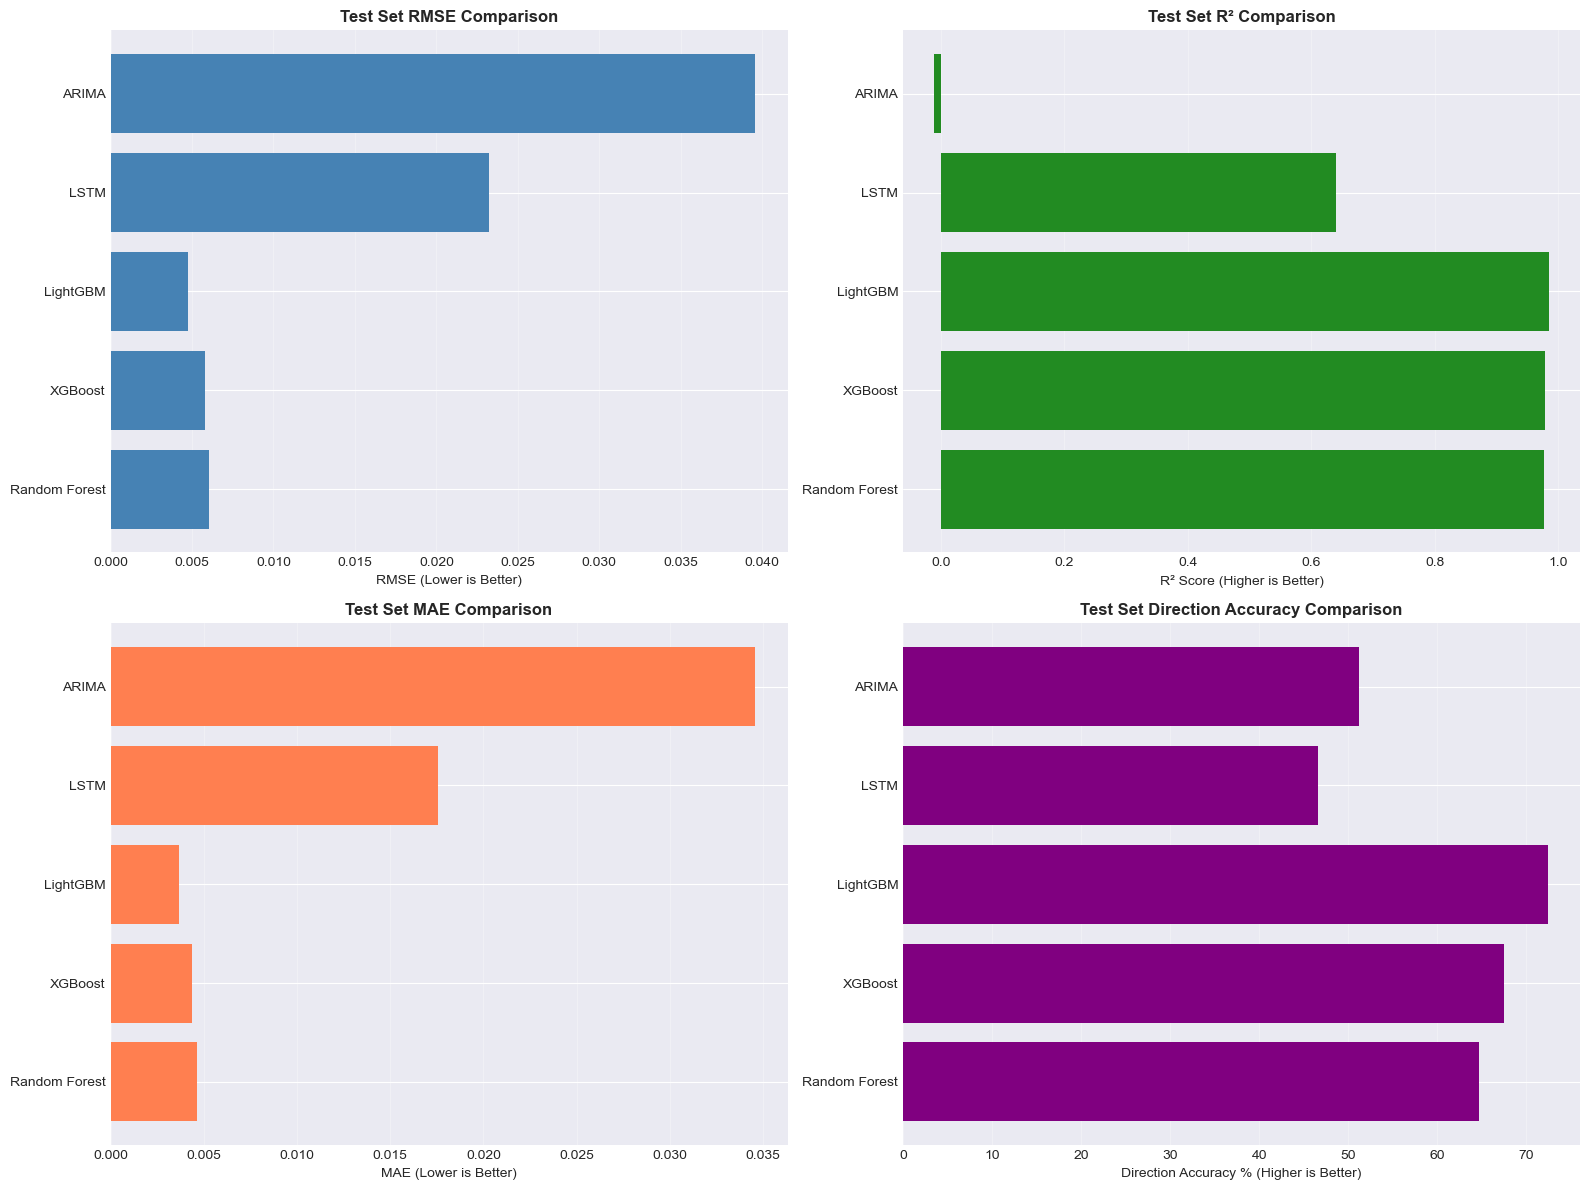

In [13]:
# CELL 13: Compare All Models

print("="*80)
print("MODEL COMPARISON - ALL MODELS")
print("="*80)

# Create comparison dataframe
comparison_df = pd.DataFrame(all_results)

# Display results
print("\n📊 Test Set Performance Comparison:")
print("\n", comparison_df[['Model', 'Test_RMSE', 'Test_MAE', 'Test_R2', 'Test_MAPE', 'Test_Direction']].to_string(index=False))

# Find best model
best_model_rmse = comparison_df.loc[comparison_df['Test_RMSE'].idxmin(), 'Model']
best_model_r2 = comparison_df.loc[comparison_df['Test_R2'].idxmax(), 'Model']
best_model_direction = comparison_df.loc[comparison_df['Test_Direction'].idxmax(), 'Model']

print(f"\n🏆 Best Model by RMSE: {best_model_rmse}")
print(f"🏆 Best Model by R²: {best_model_r2}")
print(f"🏆 Best Model by Direction Accuracy: {best_model_direction}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: RMSE Comparison
axes[0, 0].barh(comparison_df['Model'], comparison_df['Test_RMSE'], color='steelblue')
axes[0, 0].set_xlabel('RMSE (Lower is Better)')
axes[0, 0].set_title('Test Set RMSE Comparison', fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: R² Comparison
axes[0, 1].barh(comparison_df['Model'], comparison_df['Test_R2'], color='forestgreen')
axes[0, 1].set_xlabel('R² Score (Higher is Better)')
axes[0, 1].set_title('Test Set R² Comparison', fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# Plot 3: MAE Comparison
axes[1, 0].barh(comparison_df['Model'], comparison_df['Test_MAE'], color='coral')
axes[1, 0].set_xlabel('MAE (Lower is Better)')
axes[1, 0].set_title('Test Set MAE Comparison', fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 4: Direction Accuracy
axes[1, 1].barh(comparison_df['Model'], comparison_df['Test_Direction'], color='purple')
axes[1, 1].set_xlabel('Direction Accuracy % (Higher is Better)')
axes[1, 1].set_title('Test Set Direction Accuracy Comparison', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

💰 Backtesting XGBoost Trading Strategy...

Metric                         Strategy             Buy & Hold          
----------------------------------------------------------------------
Initial Capital                $10,000.00           $10,000.00          
Final Value                    $         13,589.89 $         10,239.53
Total Return (%)                             35.90                2.40
Sharpe Ratio                                  3.49                0.29
Max Drawdown (%)                             -3.20               -6.87


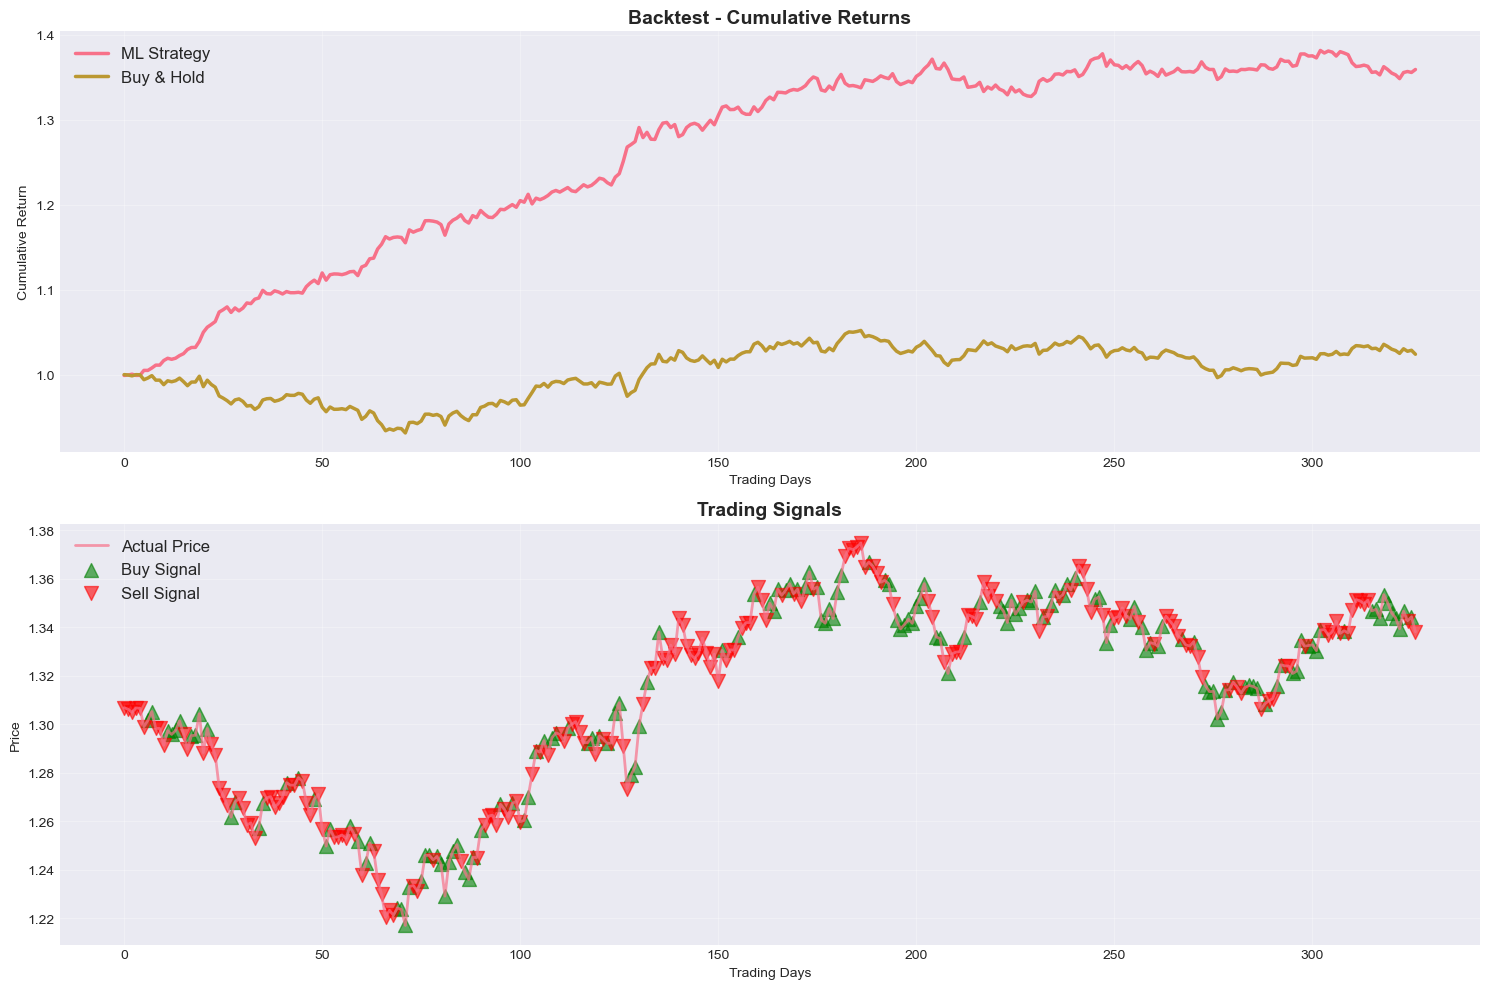


✅ Backtesting complete!


In [14]:
# CELL 14: Backtest Trading Strategy

def backtest_strategy(y_true, y_pred, initial_capital=10000, transaction_cost=0.001):
    """
    Backtest a simple trading strategy
    Buy when predicted price > current price
    Sell when predicted price < current price
    """
    
    # Get current prices (shift y_true by 1 to simulate real trading)
    current_prices = np.roll(y_true, 1)
    current_prices[0] = y_true[0]
    
    # Generate signals
    signals = np.where(y_pred > current_prices, 1, -1)
    
    # Calculate returns
    actual_returns = (y_true - current_prices) / current_prices
    strategy_returns = signals * actual_returns
    
    # Apply transaction costs
    # Cost occurs when position changes
    position_changes = np.abs(np.diff(np.concatenate([[0], signals])))
    strategy_returns = strategy_returns - (position_changes * transaction_cost)
    
    # Cumulative returns
    cumulative_strategy = np.cumprod(1 + strategy_returns)
    cumulative_buy_hold = np.cumprod(1 + actual_returns)
    
    # Final values
    final_strategy = initial_capital * cumulative_strategy[-1]
    final_buy_hold = initial_capital * cumulative_buy_hold[-1]
    
    # Calculate metrics
    total_return_strategy = (cumulative_strategy[-1] - 1) * 100
    total_return_buy_hold = (cumulative_buy_hold[-1] - 1) * 100
    
    sharpe_strategy = np.mean(strategy_returns) / np.std(strategy_returns) * np.sqrt(252) if np.std(strategy_returns) > 0 else 0
    sharpe_buy_hold = np.mean(actual_returns) / np.std(actual_returns) * np.sqrt(252) if np.std(actual_returns) > 0 else 0
    
    max_drawdown_strategy = np.min(cumulative_strategy / np.maximum.accumulate(cumulative_strategy) - 1) * 100
    max_drawdown_buy_hold = np.min(cumulative_buy_hold / np.maximum.accumulate(cumulative_buy_hold) - 1) * 100
    
    return {
        'cumulative_strategy': cumulative_strategy,
        'cumulative_buy_hold': cumulative_buy_hold,
        'final_strategy': final_strategy,
        'final_buy_hold': final_buy_hold,
        'total_return_strategy': total_return_strategy,
        'total_return_buy_hold': total_return_buy_hold,
        'sharpe_strategy': sharpe_strategy,
        'sharpe_buy_hold': sharpe_buy_hold,
        'max_drawdown_strategy': max_drawdown_strategy,
        'max_drawdown_buy_hold': max_drawdown_buy_hold,
        'signals': signals
    }

# Backtest XGBoost (usually best model)
print("💰 Backtesting XGBoost Trading Strategy...")
print("="*70)

backtest_results = backtest_strategy(y_test.values, y_test_pred_xgb, initial_capital=10000)

print(f"\n{'Metric':<30} {'Strategy':<20} {'Buy & Hold':<20}")
print("-"*70)
print(f"{'Initial Capital':<30} ${'10,000.00':<19} ${'10,000.00':<19}")
print(f"{'Final Value':<30} ${backtest_results['final_strategy']:>18,.2f} ${backtest_results['final_buy_hold']:>18,.2f}")
print(f"{'Total Return (%)':<30} {backtest_results['total_return_strategy']:>19.2f} {backtest_results['total_return_buy_hold']:>19.2f}")
print(f"{'Sharpe Ratio':<30} {backtest_results['sharpe_strategy']:>19.2f} {backtest_results['sharpe_buy_hold']:>19.2f}")
print(f"{'Max Drawdown (%)':<30} {backtest_results['max_drawdown_strategy']:>19.2f} {backtest_results['max_drawdown_buy_hold']:>19.2f}")
print("="*70)

# Plot backtest results
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Cumulative returns
axes[0].plot(backtest_results['cumulative_strategy'], label='ML Strategy', linewidth=2.5)
axes[0].plot(backtest_results['cumulative_buy_hold'], label='Buy & Hold', linewidth=2.5)
axes[0].set_title('Backtest - Cumulative Returns', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Trading Days')
axes[0].set_ylabel('Cumulative Return')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Trading signals
axes[1].plot(y_test.values, label='Actual Price', linewidth=2, alpha=0.7)
buy_signals = np.where(backtest_results['signals'] == 1)[0]
sell_signals = np.where(backtest_results['signals'] == -1)[0]
axes[1].scatter(buy_signals, y_test.values[buy_signals], color='green', marker='^', s=100, label='Buy Signal', alpha=0.6)
axes[1].scatter(sell_signals, y_test.values[sell_signals], color='red', marker='v', s=100, label='Sell Signal', alpha=0.6)
axes[1].set_title('Trading Signals', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Trading Days')
axes[1].set_ylabel('Price')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Backtesting complete!")

🔮 Generating Future Predictions...

GBPUSD=X - Next Day Prediction (XGBoost)
------------------------------------------------------------
Current Price: $1.3443
Predicted Price: $1.3433
Predicted Change: $-0.0010 (-0.07%)
📉 Signal: SELL (Price expected to decrease)


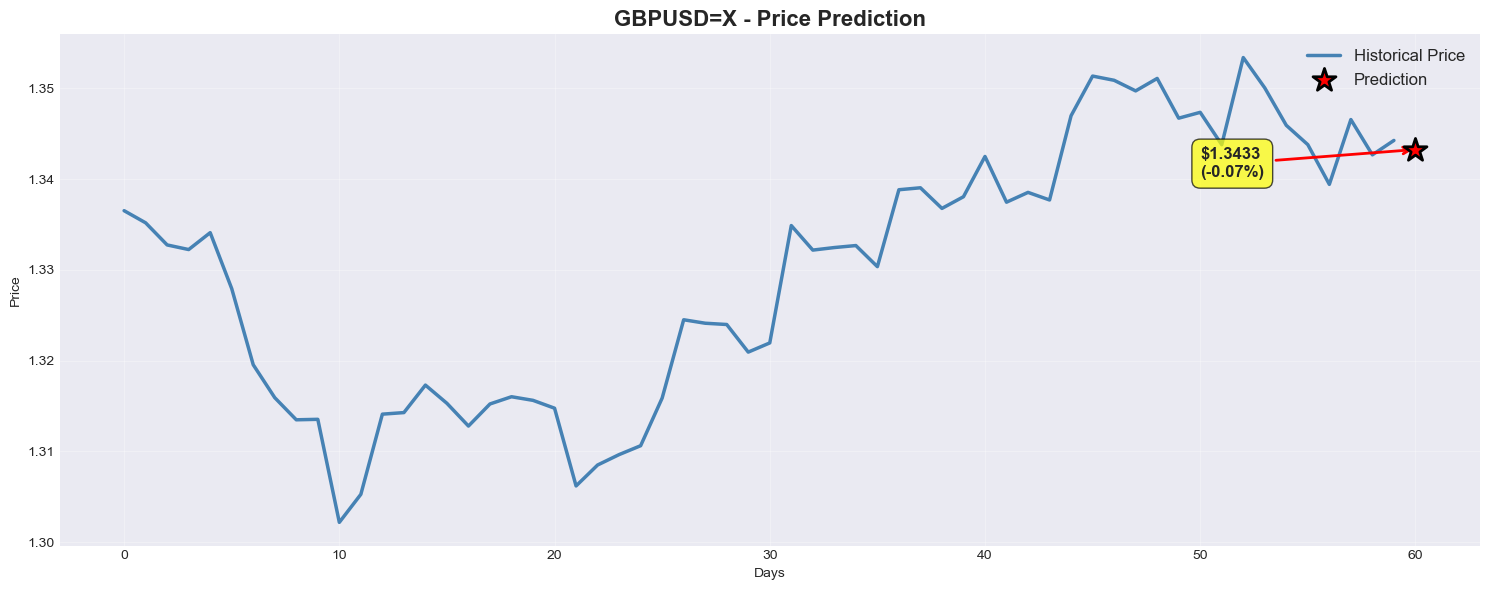


✅ Future predictions complete!


In [15]:
# CELL 15: Make Future Predictions

print("🔮 Generating Future Predictions...")
print("="*60)

# Use XGBoost for future prediction (usually best model)
# Predict next day
last_features = X.iloc[[-1]]
future_prediction_xgb = xgb_model.predict(last_features)[0]

current_price = data_with_features['Close'].iloc[-1]
predicted_change = future_prediction_xgb - current_price
predicted_change_pct = (predicted_change / current_price) * 100

print(f"\n{TICKER} - Next Day Prediction (XGBoost)")
print("-"*60)
print(f"Current Price: ${current_price:.4f}")
print(f"Predicted Price: ${future_prediction_xgb:.4f}")
print(f"Predicted Change: ${predicted_change:.4f} ({predicted_change_pct:+.2f}%)")

if predicted_change > 0:
    print(f"📈 Signal: BUY (Price expected to increase)")
else:
    print(f"📉 Signal: SELL (Price expected to decrease)")

print("="*60)

# Create visualization
fig, ax = plt.subplots(figsize=(15, 6))

# Plot recent prices
recent_data = data_with_features['Close'].tail(60)
ax.plot(range(len(recent_data)), recent_data.values, linewidth=2.5, label='Historical Price', color='steelblue')

# Plot prediction
ax.scatter(len(recent_data), future_prediction_xgb, s=300, c='red' if predicted_change < 0 else 'green', 
           marker='*', label='Prediction', zorder=5, edgecolors='black', linewidths=2)

# Add arrow
ax.annotate(f'${future_prediction_xgb:.4f}\n({predicted_change_pct:+.2f}%)',
            xy=(len(recent_data), future_prediction_xgb),
            xytext=(len(recent_data)-10, future_prediction_xgb + (predicted_change * 3)),
            arrowprops=dict(arrowstyle='->', color='red' if predicted_change < 0 else 'green', lw=2),
            fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

ax.set_title(f'{TICKER} - Price Prediction', fontsize=16, fontweight='bold')
ax.set_xlabel('Days')
ax.set_ylabel('Price')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Future predictions complete!")

In [16]:
# CELL 16: Save Trained Models

import joblib
from datetime import datetime

print("💾 Saving trained models...")

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_dir = f'models_{TICKER.replace("=", "").replace("-", "_")}_{timestamp}'

import os
os.makedirs(model_dir, exist_ok=True)

# Save models
joblib.dump(rf_model, f'{model_dir}/random_forest.pkl')
joblib.dump(xgb_model, f'{model_dir}/xgboost.pkl')
joblib.dump(lgbm_model, f'{model_dir}/lightgbm.pkl')
lstm_model.save(f'{model_dir}/lstm_model.h5')

# Save scalers
joblib.dump(scaler_X, f'{model_dir}/scaler_X.pkl')
joblib.dump(scaler_y, f'{model_dir}/scaler_y.pkl')

# Save feature columns
joblib.dump(feature_cols, f'{model_dir}/feature_columns.pkl')

# Save comparison results
comparison_df.to_csv(f'{model_dir}/model_comparison.csv', index=False)

print(f"\n✅ Models saved successfully to '{model_dir}/' directory!")
print("\nSaved files:")
print("  - random_forest.pkl")
print("  - xgboost.pkl")
print("  - lightgbm.pkl")
print("  - lstm_model.h5")
print("  - scaler_X.pkl")
print("  - scaler_y.pkl")
print("  - feature_columns.pkl")
print("  - model_comparison.csv")

💾 Saving trained models...

✅ Models saved successfully to 'models_GBPUSDX_20260117_203416/' directory!

Saved files:
  - random_forest.pkl
  - xgboost.pkl
  - lightgbm.pkl
  - lstm_model.h5
  - scaler_X.pkl
  - scaler_y.pkl
  - feature_columns.pkl
  - model_comparison.csv


In [17]:
# CELL 17: Generate Summary Report

print("\n" + "="*80)
print("FINAL SUMMARY REPORT")
print("="*80)

print(f"\n📊 Asset: {TICKER}")
print(f"📅 Analysis Period: {START_DATE} to {END_DATE}")
print(f"📈 Total Data Points: {len(data_with_features)}")
print(f"🎯 Prediction Horizon: {FORECAST_HORIZON} day(s)")
print(f"🔢 Number of Features: {len(feature_cols)}")

print("\n" + "-"*80)
print("MODEL PERFORMANCE SUMMARY (Test Set)")
print("-"*80)

for idx, row in comparison_df.iterrows():
    print(f"\n{row['Model']}:")
    print(f"  RMSE: {row['Test_RMSE']:.6f}")
    print(f"  R² Score: {row['Test_R2']:.4f}")
    print(f"  Direction Accuracy: {row['Test_Direction']:.2f}%")

print("\n" + "-"*80)
print("BACKTESTING RESULTS")
print("-"*80)
print(f"Strategy Return: {backtest_results['total_return_strategy']:.2f}%")
print(f"Buy & Hold Return: {backtest_results['total_return_buy_hold']:.2f}%")
print(f"Outperformance: {backtest_results['total_return_strategy'] - backtest_results['total_return_buy_hold']:.2f}%")

print("\n" + "-"*80)
print("NEXT DAY PREDICTION")
print("-"*80)
print(f"Current Price: ${current_price:.4f}")
print(f"Predicted Price: ${future_prediction_xgb:.4f}")
print(f"Expected Change: {predicted_change_pct:+.2f}%")
print(f"Recommendation: {'BUY' if predicted_change > 0 else 'SELL'}")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE!")
print("="*80)


FINAL SUMMARY REPORT

📊 Asset: GBPUSD=X
📅 Analysis Period: 2019-01-01 to 2026-01-17
📈 Total Data Points: 1633
🎯 Prediction Horizon: 1 day(s)
🔢 Number of Features: 120

--------------------------------------------------------------------------------
MODEL PERFORMANCE SUMMARY (Test Set)
--------------------------------------------------------------------------------

Random Forest:
  RMSE: 0.006022
  R² Score: 0.9766
  Direction Accuracy: 64.72%

XGBoost:
  RMSE: 0.005778
  R² Score: 0.9785
  Direction Accuracy: 67.48%

LightGBM:
  RMSE: 0.004755
  R² Score: 0.9854
  Direction Accuracy: 72.39%

LSTM:
  RMSE: 0.023205
  R² Score: 0.6406
  Direction Accuracy: 46.62%

ARIMA:
  RMSE: 0.039586
  R² Score: -0.0110
  Direction Accuracy: 51.23%

--------------------------------------------------------------------------------
BACKTESTING RESULTS
--------------------------------------------------------------------------------
Strategy Return: 35.90%
Buy & Hold Return: 2.40%
Outperformance: 33.50%